## 1. Kutuphaleri indirme

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

## 2. veri incelemesi 

In [3]:
df = pd.read_csv("car_sales.csv")

df.head()

,Car_Name,Company,Year,Selling_Price,Fuel_Type,Transmission,Mileage,Engine_CC
0,Civic,Honda,2020,4500000,Petrol,Automatic,14,1800
1,Corolla,Toyota,2019,3900000,Petrol,Manual,16,1600
2,City,Honda,2021,4200000,Petrol,Automatic,15,1500
3,Elantra,Hyundai,2022,5200000,Petrol,Automatic,13,2000
4,Swift,Suzuki,2018,2100000,Petrol,Manual,18,1300


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Car_Name       15 non-null     object
 1   Company        15 non-null     object
 2   Year           15 non-null     int64 
 3   Selling_Price  15 non-null     int64 
 4   Fuel_Type      15 non-null     object
 5   Transmission   15 non-null     object
 6   Mileage        15 non-null     int64 
 7   Engine_CC      15 non-null     int64 
dtypes: int64(4), object(4)
memory usage: 1.1+ KB


In [5]:
df.describe()

,Year,Selling_Price,Mileage,Engine_CC
count,15.000000,1.500000e+01,15.000000,15.000000
mean,2020.666667,5.756667e+06,14.733333,1727.666667
std,2.023669,3.917856e+06,3.881580,677.344781
min,2016.000000,9.500000e+05,9.000000,660.000000
25%,2019.500000,3.150000e+06,11.500000,1300.000000
50%,2021.000000,4.200000e+06,14.000000,1600.000000
75%,2022.000000,8.150000e+06,17.500000,2200.000000
max,2023.000000,1.450000e+07,22.000000,2800.000000


In [6]:
df.isnull().sum()

Car_Name         0
Company          0
Year             0
Selling_Price    0
Fuel_Type        0
Transmission     0
Mileage          0
Engine_CC        0
dtype: int64

## 3 EDA

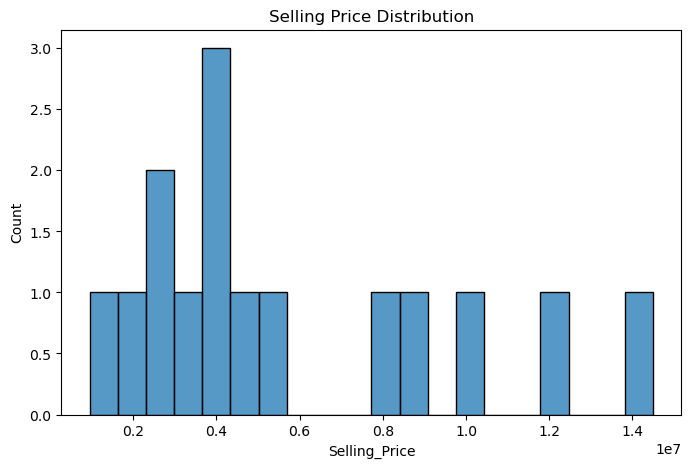

In [7]:
plt.figure(figsize=(8,5))

sns.histplot(df["Selling_Price"], bins=20)

plt.title("Selling Price Distribution")
plt.show()

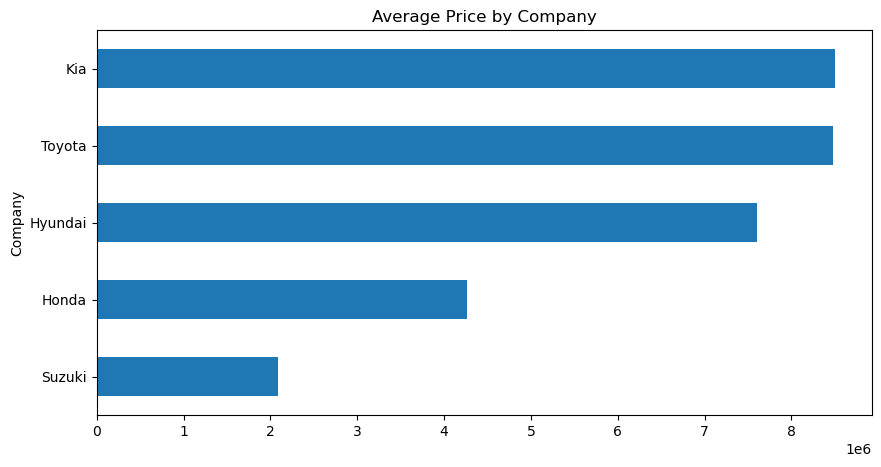

In [10]:
plt.figure(figsize=(10,5))

df.groupby("Company")["Selling_Price"]\
.mean().sort_values()\
.plot(kind="barh")

plt.title("Average Price by Company")
plt.show()

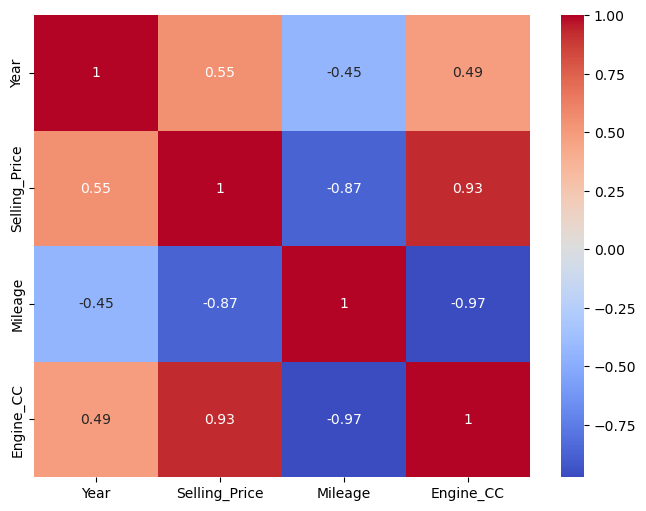

In [11]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(8,6))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.show()

## 4 Araç yaşını çıkaralım.

In [12]:
df["Car_Age"] = 2026 - df["Year"]

In [13]:
df[["Year","Car_Age"]].head()

,Year,Car_Age
0,2020,6
1,2019,7
2,2021,5
3,2022,4
4,2018,8


## 5 X VE Y secelim

In [14]:
y = df["Selling_Price"]

In [15]:
X = df.drop("Selling_Price", axis=1)

## 6. Kategorik ve Sayısal Kolonlar

In [17]:
categorical_features = X.select_dtypes(
    include="object"
).columns

numeric_features = X.select_dtypes(
    exclude="object"
).columns

In [18]:
print(categorical_features)
print(numeric_features)

Index(['Car_Name', 'Company', 'Fuel_Type', 'Transmission'], dtype='object')
Index(['Year', 'Mileage', 'Engine_CC', 'Car_Age'], dtype='object')


## 7. Preprocessing

In [20]:
categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

In [21]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ]
)

In [22]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num",
         numeric_transformer,
         numeric_features),

        ("cat",
         categorical_transformer,
         categorical_features)
    ]
)

## 8. Train Test Split

In [24]:
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

## 9. Pipeline + Model + Modeli Egitme

In [25]:
model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),

        ("regressor",
         RandomForestRegressor(
             n_estimators=200,
             random_state=42
         ))
    ]
)

In [26]:
model.fit(X_train,y_train)

,steps,"[('preprocessor', ...), ('regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [33]:
y_pred = model.predict(X_test)

## 10. SONUCLAR

In [28]:
mae = mean_absolute_error(
    y_test,
    y_pred
)

print("MAE:",mae)

MAE: 107000.0


In [29]:
rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred
    )
)

print("RMSE:",rmse)

RMSE: 107196.2763656773


In [30]:
r2 = r2_score(
    y_test,
    y_pred
)

print("R2 Score:",r2)

R2 Score: 0.9781815664556962


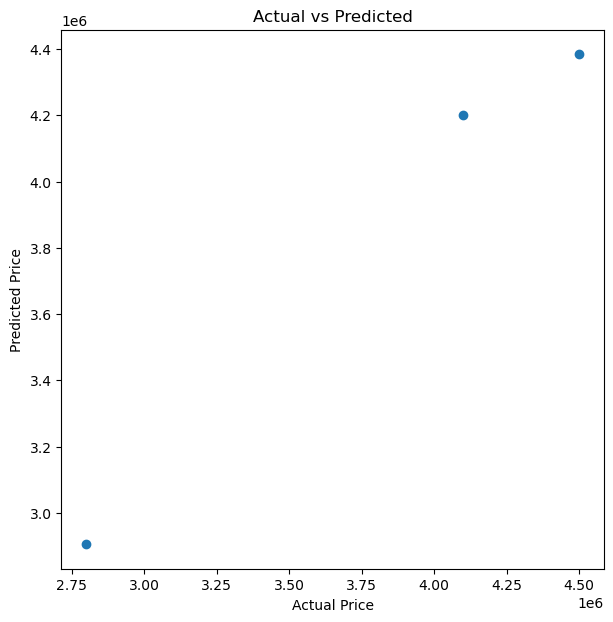

In [31]:
plt.figure(figsize=(7,7))

plt.scatter(
    y_test,
    y_pred
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.title(
    "Actual vs Predicted"
)

plt.show()